In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

In [10]:
def get_angles(pos, k, d):
    """
    Get the angles for the positional encoding
    
    Arguments:
        pos -- Tensor of shape (positions, 1) containing the positions [0, 1, ..., N-1]
        k -- Tensor of shape (1, d) containing the dimension span [0, 1, 2, ..., d-1]
        d (int) -- Encoding size
    
    Returns:
        angles -- Tensor of shape (positions, d)
    """
    i = k // 2
    angles = pos / (10000 ** (2 * i / d))
    return angles

In [52]:
get_angles(torch.arange(10).unsqueeze(1),torch.arange(10),1-0)

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e+00, 1.0000e-08, 1.0000e-08, 1.0000e-16, 1.0000e-16,
         1.0000e-24, 1.0000e-24, 1.0000e-32, 1.0000e-32],
        [2.0000e+00, 2.0000e+00, 2.0000e-08, 2.0000e-08, 2.0000e-16, 2.0000e-16,
         2.0000e-24, 2.0000e-24, 2.0000e-32, 2.0000e-32],
        [3.0000e+00, 3.0000e+00, 3.0000e-08, 3.0000e-08, 3.0000e-16, 3.0000e-16,
         3.0000e-24, 3.0000e-24, 3.0000e-32, 3.0000e-32],
        [4.0000e+00, 4.0000e+00, 4.0000e-08, 4.0000e-08, 4.0000e-16, 4.0000e-16,
         4.0000e-24, 4.0000e-24, 4.0000e-32, 4.0000e-32],
        [5.0000e+00, 5.0000e+00, 5.0000e-08, 5.0000e-08, 5.0000e-16, 5.0000e-16,
         5.0000e-24, 5.0000e-24, 5.0000e-32, 5.0000e-32],
        [6.0000e+00, 6.0000e+00, 6.0000e-08, 6.0000e-08, 6.0000e-16, 6.0000e-16,
         6.0000e-24, 6.0000e-24, 6.0000e-32, 6.0000e-32],
        [7.0000e+00, 7.0000

In [46]:
torch.arange(20).unsqueeze(0)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19]])

In [11]:
def positional_encoding(positions, d):
    """
    Precomputes a matrix with all the positional encodings 
    
    Arguments:
        positions (int) -- Maximum number of positions to be encoded 
        d (int) -- Encoding size 
    
    Returns:
        pos_encoding -- Tensor of shape (1, positions, d) with the positional encodings
    """
    pos = torch.arange(positions, dtype=torch.float32).unsqueeze(1)  # (positions, 1)
    k = torch.arange(d, dtype=torch.float32).unsqueeze(0)            # (1, d)

    print(pos,k)
    angle_rads = get_angles(pos, k, d)
    angle_rads[:, 0::2] = torch.sin(angle_rads[:, 0::2])  # Apply sin to even indices
    angle_rads[:, 1::2] = torch.cos(angle_rads[:, 1::2])  # Apply cos to odd indices
    
    pos_encoding = angle_rads.unsqueeze(0)  # (1, positions, d)
    return pos_encoding

In [24]:
tst = positional_encoding(10,1)
tst

tensor([[[ 0.0000],
         [ 0.8415],
         [ 0.9093],
         [ 0.1411],
         [-0.7568],
         [-0.9589],
         [-0.2794],
         [ 0.6570],
         [ 0.9894],
         [ 0.4121]]])

In [53]:
def viz_position(pos,dim):
    pos_encoding = positional_encoding(pos,dim)
    print(pos_encoding.shape)
    plt.pcolormesh(pos_encoding[0].numpy(), cmap='RdBu')
    plt.xlabel('d')
    plt.xlim((0, 512))
    plt.ylabel('Position')
    plt.colorbar()
    plt.show()

torch.Size([1, 10, 500])


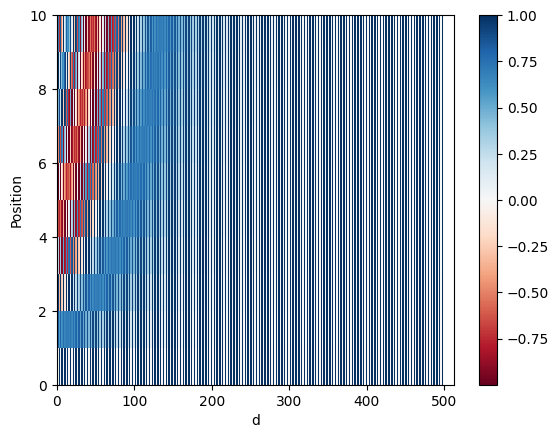

In [57]:
viz_position(10,500)

In [ ]:
def create_padding_mask(decoder_token_ids):
    """
    Creates a matrix mask for the padding cells
    
    Arguments:
        decoder_token_ids -- Tensor of shape (batch_size, seq_len)
    
    Returns:
        mask -- Tensor of shape (batch_size, 1, seq_len) with 1s for valid positions, 0s for padding
    """
    mask = (decoder_token_ids != 0).float()  # 1 for non-zero, 0 for zero
    return mask.unsqueeze(1)  # (batch_size, 1, seq_len)